In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
import os

# Define the path to the directory containing the modules
module_path = '/content/drive/My Drive/Kernel_GLM_bis'

# Add the directory to the Python path
if os.path.exists(module_path):
    sys.path.append(module_path)
    print(f"'{module_path}' added to Python path. You can now import modules from this directory.")
else:
    print(f"Error: Directory '{module_path}' not found. Please check the path.")

'/content/drive/My Drive/Kernel_GLM_bis' added to Python path. You can now import modules from this directory.


In [3]:
!pip install pykeops > install.log

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from math import*
import pandas as pd

from rkhs_glm_scaled_KeOps import RKHSGLM_KeOps

from pseudo_label_experiment_general_KeOps import FAMILIES, make_data, mean, KGLM_covariate_shift, a_logpartition, run_experiment

import torch
from pykeops.torch import LazyTensor
torch.set_default_dtype(torch.float32)
torch.set_float32_matmul_precision("high")


# (Optional) keep BLAS quiet on CPU if you still do any host ops
#os.environ["OMP_NUM_THREADS"] = "1"
#os.environ["OPENBLAS_NUM_THREADS"] = "1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
# before creating any tensors/models:
torch.set_num_threads(min(8, torch.get_num_threads() or 8))  # or your core count
torch.set_num_interop_threads(1)
os.environ["CUDA_VISIBLE_DEVICES"] = ""

os.environ["OMP_NUM_THREADS"] = "8"      # set to your physical cores
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK
Device: cuda


In [ ]:
#base = module_path
#outdir = os.path.join(base, "results_logistic_ablation")
#os.makedirs(outdir, exist_ok=True)  # creates it if missing

In [5]:
import time
# Make sure your KGLM_covariate_shift class has the fit_and_evaluate_all_tildes_keops method!

# 1. Define the true function
def fcn(x):
    return 1.5 * np.cos(2 * np.pi * x)

# 2. Parameters
beta = 1.8
n = 16000
n_0 = n
B = n ** 0.45
lbd_min = 1e-5
lbd_max = 1e-3
lbd_tilde_grid = [1e-6, 1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
N_test = 10000

num_seeds = 50
seed_list = np.arange(29, 29 + num_seeds)

# 3. --- Warm-up KeOps Compiler ---
print("Warming up KeOps compiler (this might take 30-60 seconds)...")
dummy_test = KGLM_covariate_shift(
    100, 100, B, fcn=fcn, family='logistic', kernel='sobolev_intercept', seed=0
)
# We just pass a single lambda to make it fast
_ = dummy_test.fit_and_evaluate_all_tildes_keops(
    [1e-3], N_test=100, seed=0, rho=0.5, beta=beta, lbd_min=lbd_min, lbd_max=lbd_max
)
print("Warm-up complete! CUDA binaries cached.\n")

# 4. --- Sequential Execution ---
results = []
print(f"Starting sequential GPU Monte Carlo for {num_seeds} seeds...")

for i, seed in enumerate(seed_list):
    start_time = time.time() # Track time to see how fast the GPU is!

    # Initialize the data for this seed
    test = KGLM_covariate_shift(
        n, n_0, B,
        fcn=fcn,
        family='logistic',
        kernel='sobolev_intercept',
        seed=int(seed)
    )

    # Run the optimized KEOPS inner loop
    risks = test.fit_and_evaluate_all_tildes_keops(
        lbd_tilde_list=lbd_tilde_grid,
        N_test=N_test,
        seed=int(seed),
        rho=0.5,
        beta=beta,
        lbd_min=lbd_min,
        lbd_max=lbd_max
    )

    results.append(risks)
    elapsed = time.time() - start_time
    print(f"Seed {seed} ({i+1}/{num_seeds}) finished in {elapsed:.2f} seconds.")

# 5. --- Process Results ---
risk_matrix = np.array(results).T
mean_risks = np.mean(risk_matrix, axis=1)
std_errors = np.std(risk_matrix, axis=1, ddof=1) / np.sqrt(num_seeds)

print("\n--- Final Results ---")
for i, lbd in enumerate(lbd_tilde_grid):
    print(f"lbd_tilde: {lbd:.1e} | Mean Excess Risk: {mean_risks[i]:.5f} +/- {std_errors[i]:.5f}")

Warming up KeOps compiler (this might take 30-60 seconds)...
Warm-up complete! CUDA binaries cached.

Starting sequential GPU Monte Carlo for 50 seeds...
Seed 29 (1/50) finished in 34.16 seconds.
Seed 30 (2/50) finished in 69.80 seconds.
Seed 31 (3/50) finished in 69.68 seconds.
Seed 32 (4/50) finished in 22.18 seconds.
Seed 33 (5/50) finished in 50.98 seconds.
Seed 34 (6/50) finished in 68.37 seconds.
Seed 35 (7/50) finished in 51.67 seconds.
Seed 36 (8/50) finished in 26.87 seconds.
Seed 37 (9/50) finished in 68.99 seconds.
Seed 38 (10/50) finished in 42.64 seconds.
Seed 39 (11/50) finished in 49.69 seconds.
Seed 40 (12/50) finished in 50.39 seconds.
Seed 41 (13/50) finished in 42.49 seconds.
Seed 42 (14/50) finished in 53.72 seconds.
Seed 43 (15/50) finished in 68.04 seconds.
Seed 44 (16/50) finished in 68.64 seconds.
Seed 45 (17/50) finished in 57.01 seconds.
Seed 46 (18/50) finished in 21.08 seconds.
Seed 47 (19/50) finished in 48.34 seconds.
Seed 48 (20/50) finished in 76.05 seco

--- Summary Statistics ---
lbd_tilde: 1.0e-06 | Mean Excess Risk: 0.01208 +/- 0.00106
lbd_tilde: 1.0e-05 | Mean Excess Risk: 0.01099 +/- 0.00124
lbd_tilde: 1.0e-04 | Mean Excess Risk: 0.02005 +/- 0.00189
lbd_tilde: 5.0e-04 | Mean Excess Risk: 0.07507 +/- 0.00340
lbd_tilde: 1.0e-03 | Mean Excess Risk: 0.11377 +/- 0.00314
lbd_tilde: 5.0e-03 | Mean Excess Risk: 0.12705 +/- 0.00243
lbd_tilde: 1.0e-02 | Mean Excess Risk: 0.12705 +/- 0.00243

--- Paired T-Test Results ---
Testing if risk for lbd=1.0e-06 is LESS than lbd=1.0e-03
T-statistic: -32.1946
P-value:     6.3125e-35
Result: SIGNIFICANT. The undersmoothed penalty yields a strictly lower excess risk.


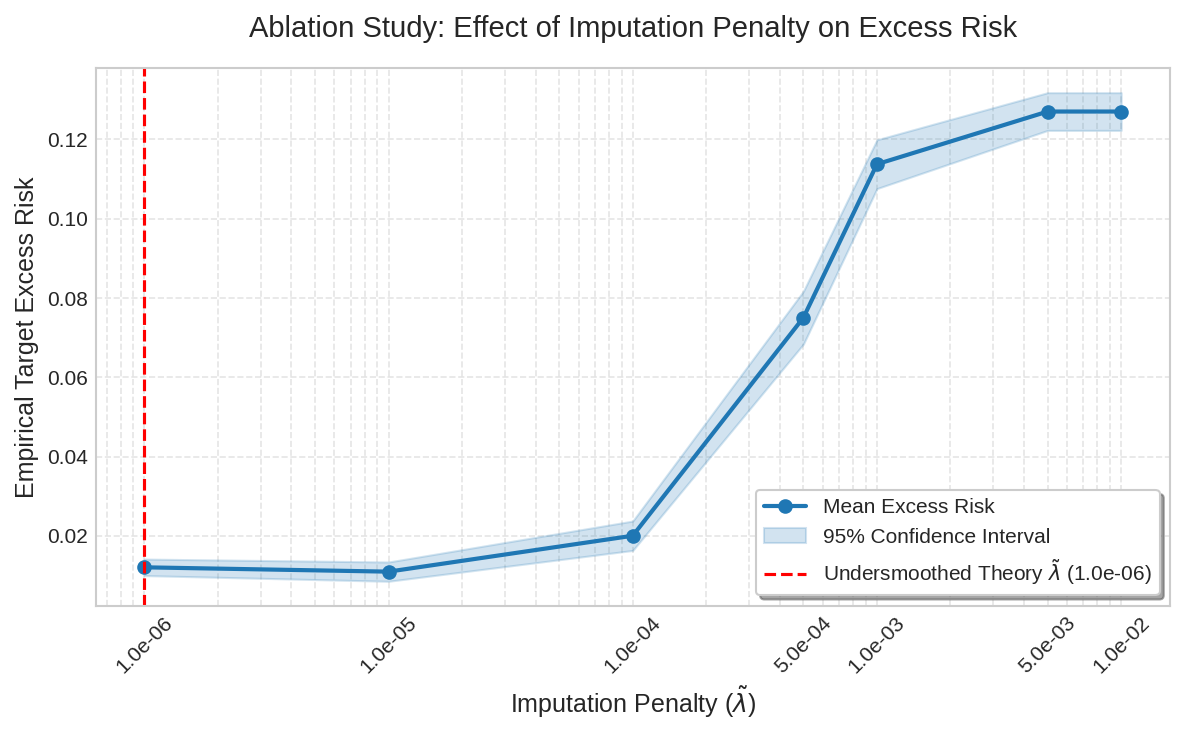

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. Process the Results ---
# Convert results to a numpy matrix: rows = lbd_tilde, cols = independent runs (seeds)
risk_matrix = np.array(results).T
mean_risks = np.mean(risk_matrix, axis=1)
std_errors = np.std(risk_matrix, axis=1, ddof=1) / np.sqrt(num_seeds)

print("--- Summary Statistics ---")
for i, lbd in enumerate(lbd_tilde_grid):
    print(f"lbd_tilde: {lbd:.1e} | Mean Excess Risk: {mean_risks[i]:.5f} +/- {std_errors[i]:.5f}")


# --- 2. Statistical Significance Testing ---
# Let's say index 0 (1e-6) is your undersmoothed theory-optimal lambda
# Let's say index 4 (1e-3) is a standard/larger lambda baseline
idx_undersmooth = 0
idx_baseline = 4

undersmooth_risks = risk_matrix[idx_undersmooth, :]
baseline_risks = risk_matrix[idx_baseline, :]

# Perform a paired t-test
t_stat, p_value = stats.ttest_rel(undersmooth_risks, baseline_risks, alternative='less')

print("\n--- Paired T-Test Results ---")
print(f"Testing if risk for lbd={lbd_tilde_grid[idx_undersmooth]:.1e} is LESS than lbd={lbd_tilde_grid[idx_baseline]:.1e}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4e}")

if p_value < 0.05:
    print("Result: SIGNIFICANT. The undersmoothed penalty yields a strictly lower excess risk.")
else:
    print("Result: NOT SIGNIFICANT. We do not have enough evidence at alpha=0.05.")


# --- 3. Plotting with Confidence Bands ---
# Calculate 95% Confidence Intervals (1.96 * standard error)
ci_95 = 1.96 * std_errors
lower_bound = mean_risks - ci_95
upper_bound = mean_risks + ci_95

plt.figure(figsize=(8, 5), dpi=150)
plt.style.use('seaborn-v0_8-whitegrid') # Clean, academic look

# Plot the mean trend line
plt.plot(lbd_tilde_grid, mean_risks, marker='o', linestyle='-', linewidth=2,
         color='#1f77b4', markersize=6, label='Mean Excess Risk')

# Add the shaded 95% Confidence Band
plt.fill_between(lbd_tilde_grid, lower_bound, upper_bound,
                 color='#1f77b4', alpha=0.2, label='95% Confidence Interval')

# Highlight your theoretical undersmoothed lambda
undersmoothed_lbd = lbd_tilde_grid[idx_undersmooth]
plt.axvline(x=undersmoothed_lbd, color='red', linestyle='--', linewidth=1.5,
            label=f'Undersmoothed Theory $\\tilde{{\\lambda}}$ ({undersmoothed_lbd:.1e})')

# Formatting the axes
plt.xscale('log') # Log scale for the penalty grid
plt.xlabel(r'Imputation Penalty ($\tilde{\lambda}$)', fontsize=12)
plt.ylabel('Empirical Target Excess Risk', fontsize=12)
plt.title('Ablation Study: Effect of Imputation Penalty on Excess Risk', fontsize=14, pad=15)

# Ticks and Grid
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xticks(lbd_tilde_grid, [f"{val:.1e}" for val in lbd_tilde_grid], rotation=45)

# Legend
plt.legend(loc='best', fontsize=10, frameon=True, shadow=True)

# Tight layout ensures labels aren't cut off
plt.tight_layout()

# Save for your paper and show
plt.savefig("ablation_imputation_penalty.pdf", format='pdf', bbox_inches='tight')
plt.show()